<a href="https://colab.research.google.com/github/bahador1/BahadorColabNotes/blob/main/transformer_continual_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Continual learning with a tiny image transformer

Upload this notebook to **Google Colab → File → Upload notebook**, then **Runtime → Run all**. A CPU is sufficient; the full experiment may take a few minutes. No dataset or pretrained-weight download is needed. PyTorch, NumPy, SciPy, scikit-learn, pandas and Matplotlib are normally available in Colab. If imports fail, run `%pip install torch numpy scipy scikit-learn pandas matplotlib` in a separate cell.

## First: the mechanisms in plain English
The model learns digits **0–4** first (A), then receives digits **5–9** (B).

| Mechanism | What it does | What must be kept / what can go wrong |
|---|---|---|
| Replay | Practice a few old images while learning new ones. | Stores images and labels; small memory can miss important variation. |
| Important-weight regularization | Make it costly to change weights that mattered for A. | Stores old weights and importance scores; excessive protection prevents learning B. |
| Prototypes | Store each digit's average feature signature and compare new images to these signatures. | Stores vectors; if the encoder changes, old signatures can become stale. We freeze it here. |
| Separate adapters | Keep the transformer fixed; learn a small residual module and head for each task. | Stores task modules; selecting the correct module is a separate challenge. |
| Distillation | Ask a frozen previous model to teach the updated model how it used to respond. | Stores a teacher; retaining responses on new inputs may not retain behavior on old inputs. |
| Shift + quality checks | Ask whether incoming images differ, and separately whether they look damaged. | Requires calibration data and assumptions. Corruption is itself a distribution shift; a detector cannot identify the cause by itself. |

These mechanisms can be combined; they are not six mutually exclusive learning paradigms. The last is a **decision mechanism before adaptation**, not a weight-update method.

## What makes this a transformer?
An 8×8 image becomes **sixteen 2×2 patches**. A learned linear layer maps each patch to 32 numbers. Position embeddings retain patch locations. One transformer encoder block uses four-head self-attention to mix information among patches. Flattened output tokens become a 64-dimensional feature vector, then ten digit scores.

This is a small vision transformer trained from scratch, not a foundation model. We use PyTorch so you can see prediction, loss, backpropagation and weight updates explicitly.

## Experimental rules
- Split **training / calibration / test** data before doing anything else.
- No test image is trained on, stored in memory, or used to tune settings.
- Main comparison: all ten labels compete, with **no task ID at prediction time**.
- Trainable full-model branches start from identical A weights, reset Adam, and receive the same new batches. Replay adds 32 old examples per update, so it uses more compute. Distillation adds teacher computation. This is a teaching demonstration, not a resource-matched benchmark.
- Adapter and prototype systems are reported separately: they change the classifier and retained state.


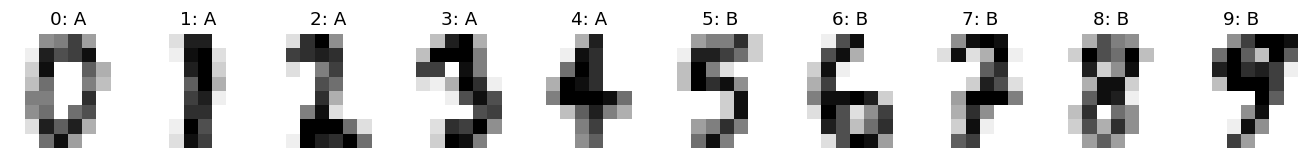

Training A/B: 541 537 | Test A/B: 180 180


In [ ]:
import copy, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.ndimage import rotate
from scipy.spatial.distance import cdist
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
import torch
from torch import nn
from torch.nn import functional as F

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.set_num_threads(2)
# CPU is intentional: this small experiment does not need a GPU.
DEVICE = torch.device('cpu')
EPOCHS_A, EPOCHS_B = 35, 30
MEMORY_PER_DIGIT = 10
EWC_STRENGTH = 300.0  # Uses the normalized empirical-Fisher penalty below.
KD_STRENGTH, TEMPERATURE = 2.0, 2.0
started = time.time()

X, y = load_digits(return_X_y=True)
X = (X / 16.0).astype('float32').reshape(-1, 1, 8, 8)
Xtr, Xrest, ytr, yrest = train_test_split(
    X, y, test_size=0.4, stratify=y, random_state=SEED)
Xcal, Xtest, ycal, ytest = train_test_split(
    Xrest, yrest, test_size=0.5, stratify=yrest, random_state=SEED)
def tensor(x): return torch.as_tensor(x, device=DEVICE)
xa, ya = tensor(Xtr[ytr < 5]), tensor(ytr[ytr < 5])
xb, yb = tensor(Xtr[ytr >= 5]), tensor(ytr[ytr >= 5])
ta, la = tensor(Xtest[ytest < 5]), tensor(ytest[ytest < 5])
tb, lb = tensor(Xtest[ytest >= 5]), tensor(ytest[ytest >= 5])
print('Training A/B:', len(xa), len(xb), '| Test A/B:', len(ta), len(tb))

fig, axes = plt.subplots(1, 10, figsize=(12, 2))
for d, ax in enumerate(axes):
    ax.imshow(Xtr[ytr == d][0, 0], cmap='gray_r', vmin=0, vmax=1)
    ax.set_title(f'{d}: {"A" if d < 5 else "B"}')
    ax.axis('off')
plt.tight_layout(); plt.show()


## 1. Build the network and expose the training step
`nn.Module` is the base class for PyTorch models. `forward()` defines predictions. PyTorch tracks the operations to calculate gradients automatically.

`optimizer.zero_grad()` clears old gradients; `loss.backward()` calculates new ones; `optimizer.step()` changes weights. Unlike scikit-learn's `partial_fit`, we explicitly write these operations.

`model.eval()` changes layer behavior for evaluation; it does **not** freeze weights. `torch.no_grad()` skips gradient recording. `requires_grad_(False)` prevents a parameter from being optimized.


In [ ]:
class TinyTransformer(nn.Module):
    def __init__(self):
        super().__init__()
        self.patch = nn.Linear(4, 32)  # Four pixels per 2x2 patch.
        self.position = nn.Parameter(torch.randn(1, 16, 32) * 0.02)
        self.block = nn.TransformerEncoderLayer(
            d_model=32, nhead=4, dim_feedforward=64,
            dropout=0.0, batch_first=True, activation='gelu')
        self.project = nn.Sequential(nn.Flatten(), nn.Linear(16*32, 64), nn.GELU())
        self.head = nn.Linear(64, 10)

    def features(self, x):
        # [batch, 1, 8, 8] -> [batch, 4 pixels, 16 patches] -> [batch, 16, 4]
        patches = F.unfold(x, kernel_size=2, stride=2).transpose(1, 2)
        tokens = self.patch(patches) + self.position
        return self.project(self.block(tokens))

    def forward(self, x):
        return self.head(self.features(x))  # Raw scores (logits), not probabilities.

@torch.no_grad()
def scores(m):
    m.eval()
    return [100 * (m(ta).argmax(1) == la).float().mean().item(),
            100 * (m(tb).argmax(1) == lb).float().mean().item()]

def update(loss, optimizer):
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

base = TinyTransformer().to(DEVICE)
optimizer = torch.optim.Adam(base.parameters(), lr=0.001)
gen = torch.Generator().manual_seed(SEED)
history_a = []
for epoch in range(EPOCHS_A):
    base.train()
    for idx in torch.randperm(len(xa), generator=gen).split(64):
        # Cross-entropy compares predictions with the correct digit labels.
        loss = F.cross_entropy(base(xa[idx]), ya[idx])
        update(loss, optimizer)
    history_a.append(scores(base))
print('Parameters:', sum(p.numel() for p in base.parameters()))
print('After A, test accuracy [old, new]:', np.round(history_a[-1], 1))


Parameters: 42698
After A, test accuracy [old, new]: [99.4  0. ]


## 2. Keep replay examples, a teacher, and important-weight estimates
**Replay:** keep ten labeled images per old digit. They come only from training data.

**Teacher:** a frozen copy of the A model, providing old predictions.

**EWC-style regularization:** save old parameters $\theta_A$, and estimate importance using the average **squared per-example loss gradient**. This is a diagonal **empirical Fisher approximation**, not the square of a batch-average gradient and not an exact Fisher calculation. We normalize its global mean to one to give the penalty a convenient numerical scale.

$$
L_{\mathrm{EWC}} = L_{\mathrm{new}} + \lambda \frac{1}{P}\sum_i \widetilde F_i(\theta_i-\theta_{A,i})^2.
$$

High importance means movement costs more; it does not mean the weight is completely locked. The saved gradients are computed before learning B. The 128 examples used for estimation need not be retained afterward.

This illustrates the mechanism of [Elastic Weight Consolidation](https://arxiv.org/abs/1612.00796), with explicitly simplified estimation and scaling.


In [ ]:
rng = np.random.default_rng(SEED)
memory_idx = np.concatenate([rng.choice(np.flatnonzero(ya.numpy() == d),
                            MEMORY_PER_DIGIT, replace=False) for d in range(5)])
mx, my = xa[memory_idx].clone(), ya[memory_idx].clone()
teacher = copy.deepcopy(base).eval()
for p in teacher.parameters(): p.requires_grad_(False)
anchor = {n: p.detach().clone() for n, p in base.named_parameters()}
fisher = {n: torch.zeros_like(p) for n, p in base.named_parameters()}
base.eval()
# One example at a time: square FIRST, then average across examples.
fi = torch.randperm(len(xa), generator=gen)[:128]
for i in fi:
    base.zero_grad()
    F.cross_entropy(base(xa[i:i+1]), ya[i:i+1]).backward()
    for n, p in base.named_parameters():
        fisher[n] += p.grad.detach().square() / len(fi)
scale = torch.cat([f.flatten() for f in fisher.values()]).mean().clamp_min(1e-12)
fisher = {n: f / scale for n, f in fisher.items()}
base.zero_grad()
param_count = sum(p.numel() for p in base.parameters())
def ewc_penalty(m):
    return sum((fisher[n] * (p-anchor[n]).square()).sum()
               for n, p in m.named_parameters()) / param_count
print('Replay stores', len(mx), 'images. EWC stores two parameter-sized arrays.')


Replay stores 50 images. EWC stores two parameter-sized arrays.


## 3. Compare replay, EWC and distillation
**Distillation:** the student matches the teacher's soft probabilities across old classes 0–4. Temperature softens those probabilities:

$$
L_{KD}=T^2\,KL\left(\operatorname{softmax}(z_{teacher,old}/T)\;\|\;
\operatorname{softmax}(z_{student,old}/T)\right).
$$

In the **Distillation** branch, the teacher and student see only new images. This is a simplified [Learning without Forgetting](https://arxiv.org/abs/1606.09282)-style idea. Keeping the relative old-class responses on new images does **not** guarantee recognition of old images or calibration between old and new classes. This branch can fail badly here; that is informative.

**Replay + distill** lets the teacher also see replay images and uses hard-label replay as well. It illustrates combination, not distillation in isolation.

The frozen branch makes no updates. All other branches start at the same A model and use Adam with a fresh optimizer state. Hyperparameters are fixed teaching settings, not selected using the test set.


**Reading the reference run:** EWC reduces movement of highly important parameters but still loses much old-task accuracy. Distillation on new images alone also retains too little. Their penalties do not guarantee retention. Replay + distillation performs better in this run, with additional old-data access and computation. We did not tune these methods against test results.

Method,Old A %,New B %,Old drop (pp)
Frozen,99.4,0.0,0.0
New only,0.6,98.3,98.9
Replay,92.2,96.7,7.2
EWC,8.9,97.8,90.6
Distillation,18.3,97.8,81.1
Replay + distill,96.1,96.7,3.3


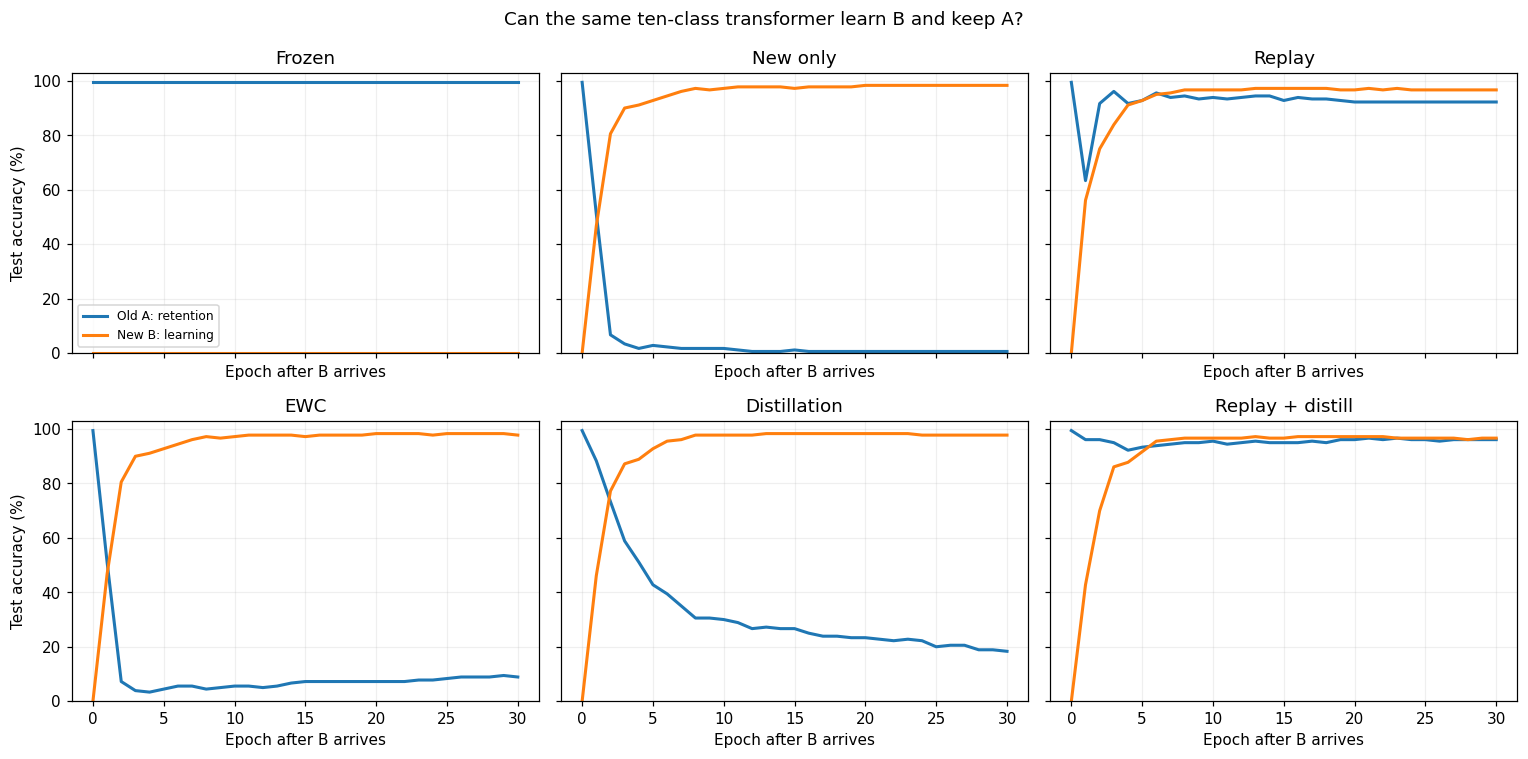

Method,Mean movement: bottom 90%,Mean movement: top 10% importance
New only,0.016064,0.013064
EWC,0.014706,0.007676


Completed new-task epoch 10 / 30
Completed new-task epoch 20 / 30
Completed new-task epoch 30 / 30
          Method  Old A %  New B %  Old drop (pp)
          Frozen     99.4      0.0            0.0
        New only      0.6     98.3           98.9
          Replay     92.2     96.7            7.2
             EWC      8.9     97.8           90.6
    Distillation     18.3     97.8           81.1
Replay + distill     96.1     96.7            3.3
  Method  Mean movement: bottom 90%  Mean movement: top 10% importance
New only                   0.016064                           0.013064
     EWC                   0.014706                           0.007676


In [ ]:
names = ['Frozen', 'New only', 'Replay', 'EWC', 'Distillation', 'Replay + distill']
models = {name: copy.deepcopy(base) for name in names}
histories = {name: [history_a[-1]] for name in names}
opts = {name: torch.optim.Adam(m.parameters(), lr=0.001)
        for name, m in models.items() if name != 'Frozen'}
training_rng = torch.Generator().manual_seed(123)
for epoch in range(EPOCHS_B):
    for idx in torch.randperm(len(xb), generator=training_rng).split(64):
        nx, ny = xb[idx], yb[idx]
        mi = torch.randint(len(mx), (32,), generator=training_rng)
        for name in names[1:]:
            m = models[name]
            m.train()
            replay = name in ['Replay', 'Replay + distill']
            xx = torch.cat([nx, mx[mi]]) if replay else nx
            yy = torch.cat([ny, my[mi]]) if replay else ny
            student_logits = m(xx)
            loss = F.cross_entropy(student_logits, yy)
            if name == 'EWC':
                loss = loss + EWC_STRENGTH * ewc_penalty(m)
            if name in ['Distillation', 'Replay + distill']:
                with torch.no_grad():
                    target = F.softmax(teacher(xx)[:, :5] / TEMPERATURE, dim=1)
                kd = F.kl_div(
                    F.log_softmax(student_logits[:, :5] / TEMPERATURE, dim=1),
                    target, reduction='batchmean') * TEMPERATURE**2
                loss = loss + KD_STRENGTH * kd
            update(loss, opts[name])
    for name, m in models.items(): histories[name].append(scores(m))
    if (epoch+1) % 10 == 0:
        print('Completed new-task epoch', epoch+1, '/', EPOCHS_B)

rows=[]
for name in names:
    old, new = histories[name][-1]
    rows.append([name, old, new, history_a[-1][0]-old])
results = pd.DataFrame(rows, columns=['Method', 'Old A %', 'New B %', 'Old drop (pp)'])
display(results.round(1))
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)
for ax, name in zip(axes.flat, names):
    h = np.array(histories[name])
    ax.plot(h[:, 0], label='Old A: retention', lw=2)
    ax.plot(h[:, 1], label='New B: learning', lw=2)
    ax.set(title=name, ylim=(0, 103), xlabel='Epoch after B arrives')
    ax.grid(alpha=.2)
axes[0, 0].legend(fontsize=8)
axes[0, 0].set_ylabel('Test accuracy (%)')
axes[1, 0].set_ylabel('Test accuracy (%)')
fig.suptitle('Can the same ten-class transformer learn B and keep A?')
plt.tight_layout(); plt.show()

# Inspect whether high-importance weights move less under EWC.
f = torch.cat([v.flatten() for v in fisher.values()]).numpy()
cut = np.quantile(f, .9)
movement=[]
for name in ['New only', 'EWC']:
    delta = torch.cat([(p.detach()-anchor[n]).abs().flatten()
                       for n, p in models[name].named_parameters()]).numpy()
    movement.append([name, delta[f < cut].mean(), delta[f >= cut].mean()])
display(pd.DataFrame(movement, columns=['Method', 'Mean movement: bottom 90%',
                                      'Mean movement: top 10% importance']))


## 4. Prototypes: learn by updating stored feature summaries
Freeze the A encoder. For class $c$, keep its mean normalized feature:
$$
\mu_c=\frac{1}{N_c}\sum_{y_i=c}\frac{f(x_i)}{\|f(x_i)\|}.
$$
Predict the closest prototype in Euclidean distance. Old prototypes are built when A is available; new prototypes are added when B arrives. After summarization only vectors and counts are needed, not the source images.

Unlike weight adaptation, adding prototypes does not backpropagate. This is still an update to the prediction system. Old vectors remain unchanged, but **old accuracy can drop** when new prototypes start competing with them. Also, an encoder trained only on A may represent B poorly.

This is a fixed-encoder nearest-class-mean demonstration, **not a reproduction of [iCaRL](https://arxiv.org/abs/1611.07725)**, which combines representation learning, exemplars and other mechanisms.


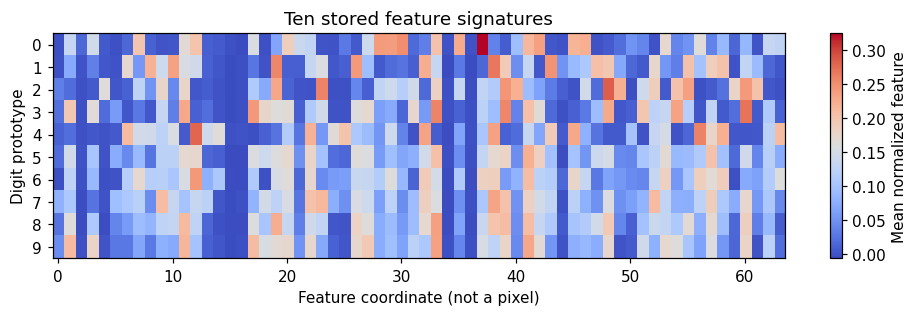

Prototypes: A before adding B=98.3%; A after=95.0%; B after=65.0%
Stored summaries: (10, 64) + 10 counts


In [ ]:
@torch.no_grad()
def embed(x):
    teacher.eval()
    return F.normalize(teacher.features(x), dim=1)
za, zb, zta, ztb = embed(xa), embed(xb), embed(ta), embed(tb)
# A summaries would be retained at the end of A, before receiving B.
proto_a = torch.stack([za[ya == c].mean(0) for c in range(5)])
count_a = torch.tensor([(ya == c).sum() for c in range(5)])
proto_b = torch.stack([zb[yb == c].mean(0) for c in range(5, 10)])
count_b = torch.tensor([(yb == c).sum() for c in range(5, 10)])
prototypes = torch.cat([proto_a, proto_b])
counts = torch.cat([count_a, count_b])
def proto_predict(z, bank): return torch.cdist(z, bank).argmin(1)
def pct(pred, labels): return 100 * (pred == labels).float().mean().item()
proto_before = pct(proto_predict(zta, proto_a), la)
proto_old = pct(proto_predict(zta, prototypes), la)
proto_new = pct(proto_predict(ztb, prototypes), lb)
print(f'Prototypes: A before adding B={proto_before:.1f}%; '
      f'A after={proto_old:.1f}%; B after={proto_new:.1f}%')
print('Stored summaries:', tuple(prototypes.shape), '+', len(counts), 'counts')
fig, ax = plt.subplots(figsize=(9, 3))
im = ax.imshow(prototypes.numpy(), aspect='auto', cmap='coolwarm')
ax.set(xlabel='Feature coordinate (not a pixel)', ylabel='Digit prototype',
       yticks=range(10), title='Ten stored feature signatures')
fig.colorbar(im, ax=ax, label='Mean normalized feature')
plt.tight_layout(); plt.show()


## 5. Separate adapters, and the routing problem
An adapter computes **h + up(ReLU(down(h)))**: a small learned correction to frozen features. Here it is attached after the transformer feature extractor. Each task also gets a five-class head. This is an educational bottleneck-adapter variant, not an exact implementation of [Houlsby et al.](https://proceedings.mlr.press/v97/houlsby19a.html).

We train adapter A while A is available, freeze it, then train adapter B. The shared encoder stays frozen throughout. Cached training features make this fast; caches can be discarded afterward.

We evaluate two cases:
1. **Automatic routing:** the nearest prototype predicts whether an image belongs to A or B. Then the selected adapter predicts its digit. This requires keeping the prototype bank too.
2. **Known-task routing:** tell the system the correct task. This is an oracle diagnostic with extra information and is **not comparable** to the main ten-class results.

Old parameters can be perfectly preserved while automatic routing still causes errors. This is why keeping adapters is only part of the solution.


In [ ]:
class AdapterHead(nn.Module):
    def __init__(self):
        super().__init__()
        self.down = nn.Linear(64, 16)
        self.up = nn.Linear(16, 64)
        self.head = nn.Linear(64, 5)
        nn.init.zeros_(self.up.weight)
        nn.init.zeros_(self.up.bias)
    def forward(self, h):
        return self.head(h + self.up(F.relu(self.down(h))))

# Cache raw frozen features (prototypes used normalized features).
with torch.no_grad():
    ha, hb = teacher.features(xa), teacher.features(xb)
    hta, htb = teacher.features(ta), teacher.features(tb)
torch.manual_seed(202)
adapters = nn.ModuleDict({'A': AdapterHead(), 'B': AdapterHead()})

def train_adapter(adapter, h, labels):
    opt = torch.optim.Adam(adapter.parameters(), lr=.003)
    ag = torch.Generator().manual_seed(202)
    for epoch in range(40):
        adapter.train()
        for idx in torch.randperm(len(h), generator=ag).split(64):
            update(F.cross_entropy(adapter(h[idx]), labels[idx]), opt)
    adapter.eval()

train_adapter(adapters['A'], ha, ya)
old_snapshot = {n: p.detach().clone() for n, p in adapters['A'].named_parameters()}
for p in adapters['A'].parameters(): p.requires_grad_(False)
train_adapter(adapters['B'], hb, yb-5)  # B's local labels are 0..4.
assert all(torch.equal(p, old_snapshot[n]) for n,p in adapters['A'].named_parameters())

@torch.no_grad()
def routed(h, z):
    task_b = proto_predict(z, prototypes) >= 5
    a_pred = adapters['A'](h).argmax(1)
    b_pred = adapters['B'](h).argmax(1) + 5
    return torch.where(task_b, b_pred, a_pred)
with torch.no_grad():
    adapter_rows = [
        ['Automatic prototype routing', pct(routed(hta,zta),la), pct(routed(htb,ztb),lb)],
        ['Known task (oracle; extra information)',
         pct(adapters['A'](hta).argmax(1),la), pct(adapters['B'](htb).argmax(1)+5,lb)]]
display(pd.DataFrame(adapter_rows, columns=['Routing', 'Old A %', 'New B %']).round(1))
print('Router task accuracy A/B:',
      round(100*(proto_predict(zta,prototypes)<5).float().mean().item(),1),
      round(100*(proto_predict(ztb,prototypes)>=5).float().mean().item(),1))
print('Parameters per adapter + head:', sum(p.numel() for p in adapters['B'].parameters()))
print('Adapter A weights unchanged after learning B: verified')


Routing,Old A %,New B %
Automatic prototype routing,95.6,79.4
Known task (oracle; extra information),99.4,91.1


                               Routing  Old A %  New B %
           Automatic prototype routing     95.6     79.4
Known task (oracle; extra information)     99.4     91.1
Router task accuracy A/B: 95.6 87.8
Parameters per adapter + head: 2453
Adapter A weights unchanged after learning B: verified


## 6. Detect a shift, then separately inspect input quality
This is a **separate input-monitoring experiment** on old digits 0–4. We keep the class mix fixed across scenarios, so the deliberate change is image appearance, not newly introduced classes.

- **Clean:** held-out upright digits.
- **Rotated:** the same held-out images rotated 20 degrees, as a candidate new environment.
- **Corrupted:** the same images with strong random salt-and-pepper corruption.

**Change detector:** a permutation test with an RBF-kernel maximum mean discrepancy (MMD) statistic compares a calibration reference batch with an incoming batch. Bandwidth is the median pairwise squared distance of the pooled images, without using group labels. The p-value counts how often shuffled group assignments produce a statistic at least as large. It is **not the probability that data is corrupted**.

**Quality check:** compare average neighbor-to-neighbor pixel roughness against a threshold bootstrapped from clean calibration images; also flag batches with many nearly blank images. These are deliberately simple, corruption-specific heuristics. Rotation can also damage an 8×8 image; passing these checks does not prove data is usable.

**Decision:** suspicious quality → quarantine; detected change with passing quality → candidate shift requiring validation; otherwise → insufficient evidence to trigger adaptation. Neither branch automatically trains a model. Labels are used only afterward to illustrate performance, not in either detector.

This demo uses a fixed RBF kernel on pixels; it is not a learned deep-kernel test. The [kernel two-sample test](https://www.jmlr.org/papers/v13/gretton12a.html) supplies the statistical background. A single batch can miss shifts; repeated deployment tests require false-alarm control over time.


Incoming batch,MMD squared,Permutation p,Roughness,Old-model accuracy %,Decision
Clean,0.0109,0.270,0.2335,98.75,No shift alarm; not proof of no change
Rotated 20 degrees,0.1299,0.005,0.2101,56.25,Candidate shift: validate before adaptation
Corrupted,0.0762,0.005,0.4003,71.25,Quarantine: quality alarm; no training


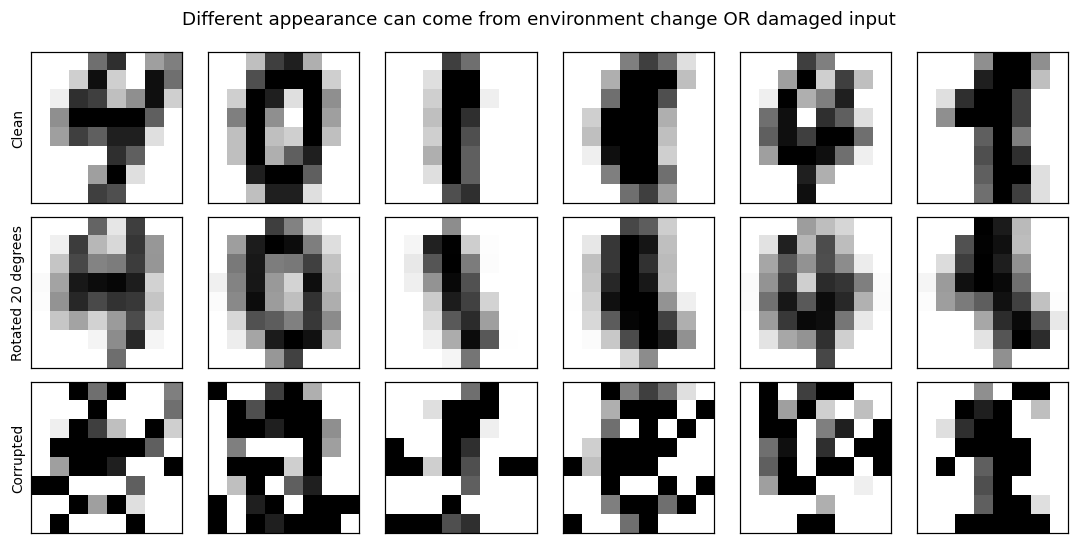

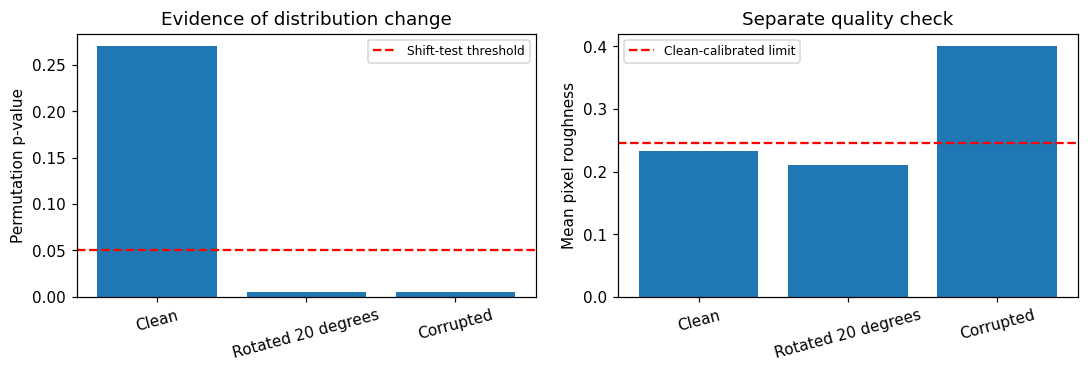

    Incoming batch  MMD squared  Permutation p  Roughness  Old-model accuracy %                                    Decision
             Clean       0.0109          0.270     0.2335                 98.75      No shift alarm; not proof of no change
Rotated 20 degrees       0.1299          0.005     0.2101                 56.25 Candidate shift: validate before adaptation
         Corrupted       0.0762          0.005     0.4003                 71.25      Quarantine: quality alarm; no training
Calibrated roughness limit: 0.2456
Finished in 0.2 minutes on this machine.


In [ ]:
cal_a = Xcal[ycal < 5, 0]
# Disjoint reference and clean-quality calibration subsets.
reference, quality_cal = cal_a[:80], cal_a[80:]
incoming = Xtest[ytest < 5, 0][:80]
incoming_labels = ytest[ytest < 5][:80]
shift_rng = np.random.default_rng(555)
rotated = np.clip(rotate(incoming, 20, axes=(1,2), reshape=False,
                         order=1, mode='constant'), 0, 1).astype('float32')
corrupted = incoming.copy()
mask = shift_rng.random(corrupted.shape) < .40
corrupted[mask] = shift_rng.integers(0, 2, size=mask.sum())
scenarios = {'Clean': incoming, 'Rotated 20 degrees': rotated, 'Corrupted': corrupted}

def roughness(images):
    return (np.abs(np.diff(images,axis=1)).mean((1,2)) +
            np.abs(np.diff(images,axis=2)).mean((1,2))) / 2
q = roughness(quality_cal)
boot = shift_rng.choice(q, size=(2000, len(incoming)), replace=True).mean(1)
quality_limit = np.quantile(boot, .99)

def mmd_test(ref, batch, permutations=199):
    z = np.concatenate([ref, batch]).reshape(len(ref)+len(batch), -1)
    distance = cdist(z,z, metric='sqeuclidean')
    bandwidth2 = np.median(distance[np.triu_indices(len(z), k=1)])
    K = np.exp(-distance / max(2*bandwidth2, 1e-12))
    n, m = len(ref), len(batch)
    # Biased MMD squared; valid as a permutation statistic with this fixed pooled kernel.
    weights = np.r_[np.ones(n)/n, -np.ones(m)/m]
    observed = weights @ K @ weights
    prng = np.random.default_rng(777)
    null_weights = np.stack([prng.permutation(weights) for _ in range(permutations)])
    null = np.einsum('bi,ij,bj->b', null_weights, K, null_weights, optimize=True)
    pvalue = (1 + np.sum(null >= observed)) / (permutations + 1)
    return float(observed), float(pvalue)

shift_rows=[]
for name, images in scenarios.items():
    stat, pvalue = mmd_test(reference, images)
    rough = roughness(images).mean()
    blank_rate = (images.std((1,2)) < .03).mean()
    bad_quality = rough > quality_limit or blank_rate > .10
    if bad_quality:
        decision = 'Quarantine: quality alarm; no training'
    elif pvalue < .05:
        decision = 'Candidate shift: validate before adaptation'
    else:
        decision = 'No shift alarm; not proof of no change'
    with torch.no_grad():
        pred = teacher(tensor(images[:,None].copy())).argmax(1).numpy()
    shift_rows.append([name, stat, pvalue, rough, 100*(pred == incoming_labels).mean(), decision])
shift_results = pd.DataFrame(shift_rows, columns=[
    'Incoming batch','MMD squared','Permutation p','Roughness','Old-model accuracy %','Decision'])
display(shift_results.round(4))
print('Calibrated roughness limit:', round(quality_limit,4))
fig, axes = plt.subplots(3, 6, figsize=(10, 5))
for row, (name, images) in enumerate(scenarios.items()):
    for col in range(6):
        axes[row,col].imshow(images[col], cmap='gray_r', vmin=0, vmax=1)
        axes[row,col].set_xticks([]); axes[row,col].set_yticks([])
        if col == 0: axes[row,col].set_ylabel(name, fontsize=9)
fig.suptitle('Different appearance can come from environment change OR damaged input')
plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1,2, figsize=(10,3.5))
axes[0].bar(scenarios.keys(), shift_results['Permutation p'])
axes[0].axhline(.05, color='red', ls='--', label='Shift-test threshold')
axes[0].set(title='Evidence of distribution change', ylabel='Permutation p-value')
axes[0].legend(fontsize=8)
axes[1].bar(scenarios.keys(), shift_results['Roughness'])
axes[1].axhline(quality_limit, color='red', ls='--', label='Clean-calibrated limit')
axes[1].set(title='Separate quality check', ylabel='Mean pixel roughness')
axes[1].legend(fontsize=8)
for ax in axes: ax.tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
print(f'Finished in {(time.time()-started)/60:.1f} minutes on this machine.')


## What to take away and what to try

**Watch both old and new accuracy.** High old accuracy with near-zero new accuracy is not successful continual learning. Neither is the reverse.

1. Change `MEMORY_PER_DIGIT` to 2 or 20 and rerun all cells. Keep it at least 1 in this notebook.
2. Change `EWC_STRENGTH` to 0, 30 or 3000. The higher setting protects weights more strongly but can obstruct learning.
3. Compare **Distillation** against **Replay + distill**. The examples on which a teacher supervises the student matter.
4. Compare adapter results with automatic vs known-task routing. The oracle row does not solve routing.
5. Change the rotation angle or corruption probability. A shift test measures difference, while the quality check tests only selected symptoms.
6. To study prototype staleness, consider what would happen if the encoder changed after prototypes were saved: the old vectors would no longer necessarily describe the new feature space. Here the encoder is frozen to avoid that problem.

**Limits:** one random seed, tiny images, two tasks, and fixed hyperparameters. These results illustrate mechanisms, not a reliable ranking of research methods. Main-branch accuracy is ten-class class-incremental evaluation; oracle adapter results use an easier task-informed setting. Prototype and adapter training use their own procedures. Timing/memory costs are not matched. No unlabeled test-time adaptation is performed: the learning experiments use labeled training examples. Only shift detection is label-free.

**Six mechanisms do not guarantee safe adaptation.** The shift monitor produces a decision recommendation; an actual deployment would still need a justified learning signal, adaptation validation, retention checks and a rollback policy appropriate to its task.


## Results saved in this notebook
The included outputs were executed successfully on CPU. The main table shows severe forgetting for New only, limited protection from EWC and new-data-only distillation, and stronger retention with replay. Adapter A parameters were checked to remain exactly unchanged. Prototype performance and routing errors are displayed separately. Exact values can differ across PyTorch versions and hardware.